# HOG + Classical Classifiers

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install mtcnn -q

import os, sys, joblib
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn import svm, metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = 'CW_Folder_UG'
GOOGLE_DRIVE_PATH = os.path.join('drive', 'My Drive', GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)
print(os.listdir(GOOGLE_DRIVE_PATH))
CODE_PATH = os.path.abspath(f'{GOOGLE_DRIVE_PATH}/Code')

if CODE_PATH not in sys.path:
    sys.path.insert(0, CODE_PATH)

print(CODE_PATH)
print(os.path.exists(os.path.join(CODE_PATH, "utils.py")))

MODELS_DIR = os.path.join(GOOGLE_DRIVE_PATH, 'Models')
os.makedirs(MODELS_DIR, exist_ok=True)



import zipfile
from pathlib import Path

src = Path(GOOGLE_DRIVE_PATH) / "CW_Dataset"
dst = Path(GOOGLE_DRIVE_PATH) / "CW_Dataset.zip"

if not dst.exists():
  with zipfile.ZipFile(dst, "w", zipfile.ZIP_DEFLATED) as zf:
      for file in src.rglob("*"):
          zf.write(file, arcname=file.relative_to(src.parent))
  print(f"Created: {dst}")

!cp '{GOOGLE_DRIVE_PATH}/CW_Dataset.zip' .
!yes|unzip -q CW_Dataset.zip
!rm CW_Dataset.zip

LOCAL_ROOT = '/content'



from utils import *

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.8 MB/s eta 0:00:00
['Models', 'CW_Dataset', 'Personal_Dataset', 'Code', 'CW_Dataset.zip', 'Personal_Dataset.zip', 'test_function.ipynb']
/content/drive/My Drive/CW_Folder_UG/Code
True


In [2]:
train_paths_all, train_labels_all, test_paths, test_labels = load_dataset(LOCAL_ROOT)

train_paths, val_paths, y_train, y_val = make_train_val_split(
    train_paths_all, train_labels_all, test_size=0.15)
y_train, y_val, y_test = np.array(y_train), np.array(y_val), np.array(test_labels)
print(f'Train:{len(train_paths)}  Val:{len(val_paths)}  Test:{len(test_paths)}')

Train: 13300 images
Test: 850 images
Train:11305  Val:1995  Test:850


In [3]:
import time

# Reference: Lab_05_Solved.ipynb (3: Extract HOG feature descriptors)
def extract_hog(paths, crop_face=False):
    kw = dict(image_size=(128, 128), crop_face=crop_face, match_resolution=crop_face)
    features = []
    for p in paths:
        img = preprocess_pipeline(p, **kw)
        features.append(hog(img, orientations=9, pixels_per_cell=(16, 16),
                            cells_per_block=(2, 2), block_norm='L2-Hys', feature_vector=True))
    return np.array(features)

t0 = time.time()
X_train = extract_hog(train_paths)
X_val   = extract_hog(val_paths)
X_test  = extract_hog(test_paths)
hog_time = time.time() - t0
print('HOG shape:', X_train.shape)
print(f'HOG extraction time: {hog_time:.1f}s')

HOG shape: (11305, 1764)
HOG extraction time: 134.2s


In [4]:
# Reference: train_SVM_solved.py + Lab_05_Solved.ipynb (1: Digit classification with Support Vector Machines (SVMs))
def train_SVM(X_train, y_train, kernel='linear', C=1.0, gamma='scale', class_weight='balanced'):
    """Train SVM. Reference: train_SVM_solved.py + Lab_05_Solved.ipynb"""
    classifier = svm.SVC(kernel=kernel, C=C, gamma=gamma, class_weight=class_weight)
    classifier.fit(X_train, y_train)
    return classifier

In [5]:
import warnings; warnings.filterwarnings('ignore')

# Grid search on a 2000-sample subset
GRID_N = 2000
rng = np.random.default_rng(SEED)
gs_idx = rng.choice(len(X_train), size=GRID_N, replace=False)
X_gs = X_train[gs_idx]
y_gs = y_train[gs_idx]
X_gs_tr, X_gs_va, y_gs_tr, y_gs_va = train_test_split(X_gs, y_gs, test_size=0.15, random_state=SEED)

# Grid search over C
# Reference: Lab_05_Solved.ipynb (1: Digit classification with Support Vector Machines (SVMs))
print(f"{'kernel':<16} {'param':>10} {'train acc':>10} {'val acc':>10} {'gap':>8}")
print('-' * 58)

best_C_linear, best_acc_linear = None, -1
for C in [0.1, 1.0, 10.0]:
    clf = train_SVM(X_gs_tr, y_gs_tr, kernel='linear', C=C)
    train_acc = accuracy_score(y_gs_tr, clf.predict(X_gs_tr))
    val_acc   = accuracy_score(y_gs_va, clf.predict(X_gs_va))
    print(f"{'linear':<16} {C:>10} {train_acc:>10.4f} {val_acc:>10.4f} {train_acc - val_acc:>8.4f}")
    if val_acc > best_acc_linear:
        best_acc_linear, best_C_linear = val_acc, C

print()
best_C_rbf, best_acc_rbf = None, -1
for C in [1.0, 10.0, 100.0]:
    clf = train_SVM(X_gs_tr, y_gs_tr, kernel='rbf', C=C)
    train_acc = accuracy_score(y_gs_tr, clf.predict(X_gs_tr))
    val_acc   = accuracy_score(y_gs_va, clf.predict(X_gs_va))
    print(f"{'rbf':<16} {C:>10} {train_acc:>10.4f} {val_acc:>10.4f} {train_acc - val_acc:>8.4f}")
    if val_acc > best_acc_rbf:
        best_acc_rbf, best_C_rbf = val_acc, C

print()
best_n_rf, best_acc_rf = None, -1
for n_estimators in [100, 200, 300]:
    clf = RandomForestClassifier(n_estimators=n_estimators, class_weight='balanced', random_state=SEED)
    clf.fit(X_gs_tr, y_gs_tr)
    train_acc = accuracy_score(y_gs_tr, clf.predict(X_gs_tr))
    val_acc   = accuracy_score(y_gs_va, clf.predict(X_gs_va))
    print(f"{'random_forest':<16} {n_estimators:>10} {train_acc:>10.4f} {val_acc:>10.4f} {train_acc - val_acc:>8.4f}")
    if val_acc > best_acc_rf:
        best_acc_rf, best_n_rf = val_acc, n_estimators

print()
print(f'Best linear C={best_C_linear}  Best rbf C={best_C_rbf}  Best RF n_estimators={best_n_rf}')

kernel                param  train acc    val acc      gap
----------------------------------------------------------
linear                  0.1     0.8488     0.6933   0.1555
linear                  1.0     0.9635     0.6600   0.3035
linear                 10.0     1.0000     0.6433   0.3567

rbf                     1.0     0.9012     0.6967   0.2045
rbf                    10.0     1.0000     0.7300   0.2700
rbf                   100.0     1.0000     0.7300   0.2700

random_forest           100     1.0000     0.6233   0.3767
random_forest           200     1.0000     0.6500   0.3500
random_forest           300     1.0000     0.6500   0.3500

Best linear C=0.1  Best rbf C=10.0  Best RF n_estimators=200


In [6]:
from sklearn.pipeline import Pipeline

# Reference: Lab_05_Solved.ipynb (1: Digit classification with Support Vector Machines (SVMs))
t0 = time.time()
classifier_linear = train_SVM(X_train, y_train, kernel='linear', C=best_C_linear)
t_linear = time.time() - t0

t0 = time.time()
classifier_rbf = train_SVM(X_train, y_train, kernel='rbf', C=best_C_rbf)
t_rbf = time.time() - t0

# Random Forest: Lecture05
t0 = time.time()
classifier_rf = RandomForestClassifier(n_estimators=best_n_rf, class_weight='balanced', random_state=SEED)
classifier_rf.fit(X_train, y_train)
t_rf = time.time() - t0

# Wrap each trained classifier in a pipeline
pipeline_linear = Pipeline([('hog', HOGTransformer(crop_face=True)), ('clf', classifier_linear)])
pipeline_rbf    = Pipeline([('hog', HOGTransformer(crop_face=True)), ('clf', classifier_rbf)])
pipeline_rf     = Pipeline([('hog', HOGTransformer(crop_face=True)), ('clf', classifier_rf)])

joblib.dump(pipeline_linear, os.path.join(MODELS_DIR, 'model_1_linear_svm.pkl'))
joblib.dump(pipeline_rbf,    os.path.join(MODELS_DIR, 'model_1_rbf_svm.pkl'))
joblib.dump(pipeline_rf,     os.path.join(MODELS_DIR, 'model_1_random_forest.pkl'))

print(f"{'model':<16} {'train acc':>10} {'val acc':>10} {'gap':>8} {'fit time':>10}")
print('-' * 58)
for name, clf, t in [('linear SVM', classifier_linear, t_linear),
                      ('rbf SVM',    classifier_rbf,    t_rbf),
                      ('random forest', classifier_rf,  t_rf)]:
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    val_acc   = accuracy_score(y_val,   clf.predict(X_val))
    print(f"{name:<16} {train_acc:>10.4f} {val_acc:>10.4f} {train_acc - val_acc:>8.4f} {t:>8.1f}s")
    print()
print(f'HOG extraction: {hog_time:.1f}s  |  Total: {hog_time + t_linear + t_rbf + t_rf:.1f}s')

model             train acc    val acc      gap   fit time
----------------------------------------------------------
linear SVM           0.7883     0.7273   0.0610    141.3s

rbf SVM              0.9978     0.7484   0.2494    203.2s

random forest        0.9989     0.6752   0.3238    175.9s

HOG extraction: 134.2s  |  Total: 654.6s


In [7]:
for fname, label in [
    ('model_1_linear_svm.pkl',   'HOG + Linear SVM'),
    ('model_1_rbf_svm.pkl',      'HOG + RBF SVM'),
    ('model_1_random_forest.pkl','HOG + Random Forest'),
]:
    mb = os.path.getsize(os.path.join(MODELS_DIR, fname)) / 1e6
    print(f'{label:<24} {mb:.2f} MB')

HOG + Linear SVM         100.74 MB
HOG + RBF SVM            120.58 MB
HOG + Random Forest      64.17 MB


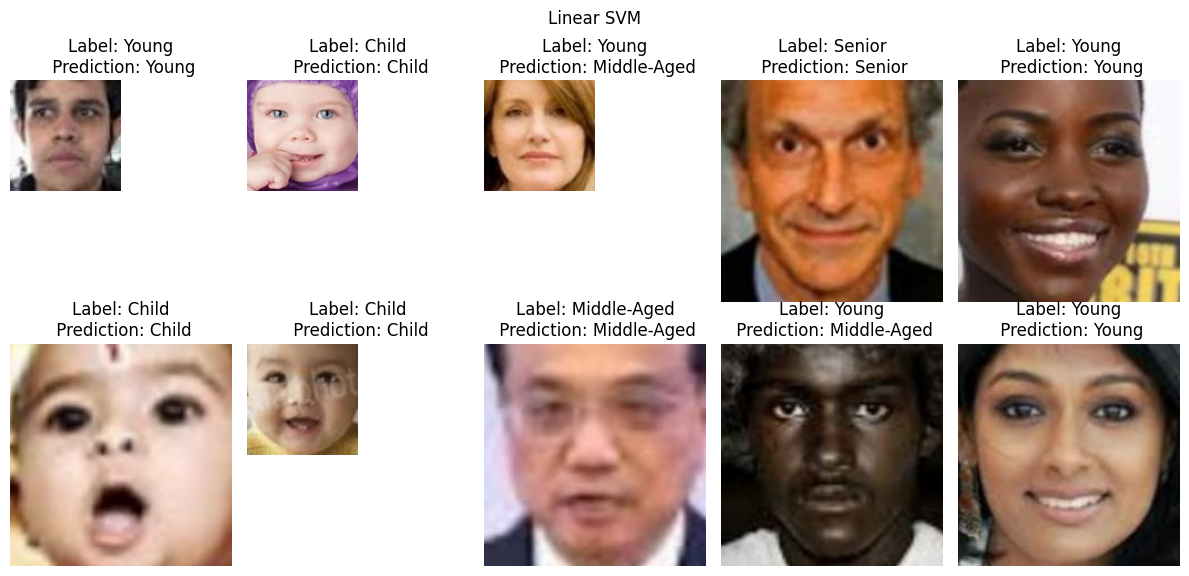

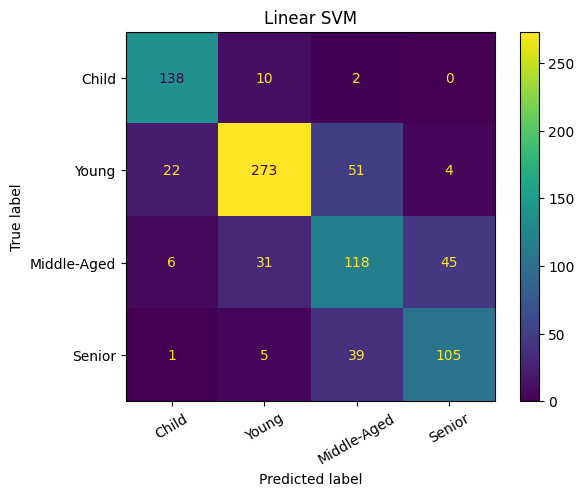

Classification report for Linear SVM:

                    precision    recall  f1-score   support

       Child       0.83      0.92      0.87       150
       Young       0.86      0.78      0.82       350
 Middle-Aged       0.56      0.59      0.58       200
      Senior       0.68      0.70      0.69       150

    accuracy                           0.75       850
   macro avg       0.73      0.75      0.74       850
weighted avg       0.75      0.75      0.75       850



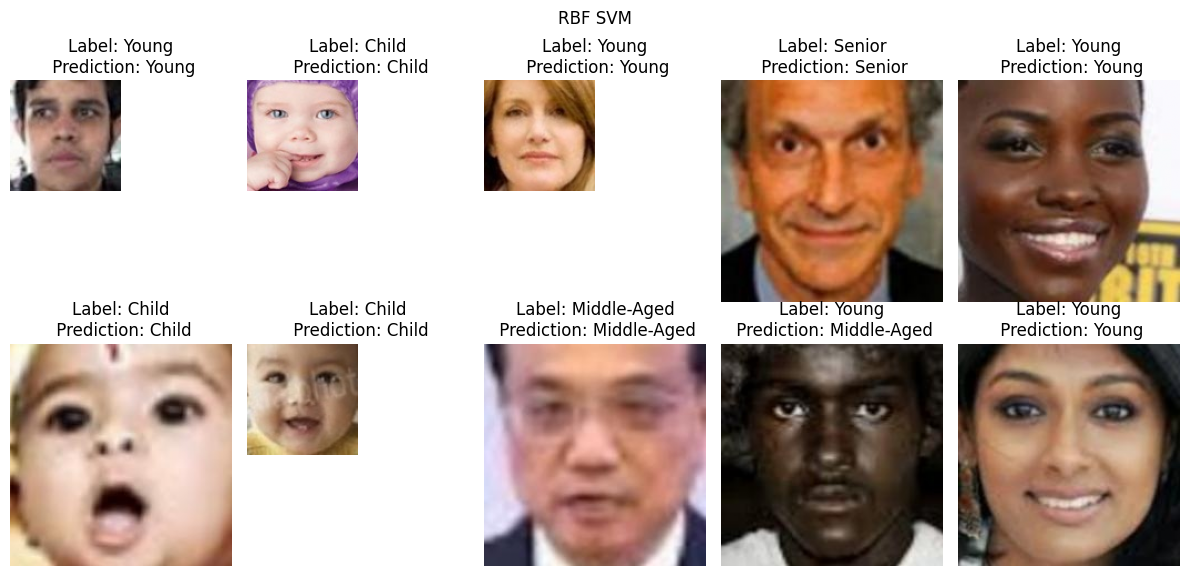

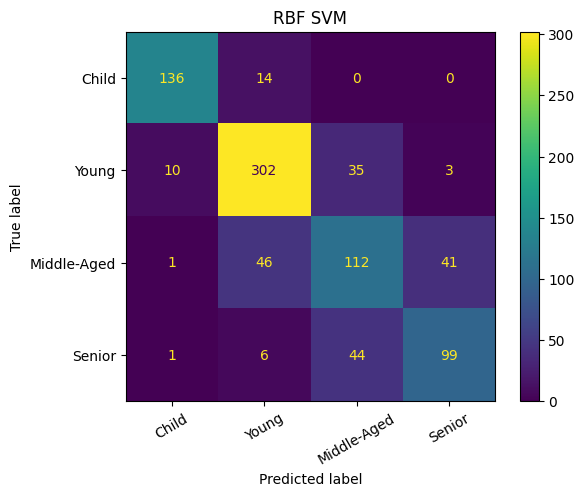

Classification report for RBF SVM:

                    precision    recall  f1-score   support

       Child       0.92      0.91      0.91       150
       Young       0.82      0.86      0.84       350
 Middle-Aged       0.59      0.56      0.57       200
      Senior       0.69      0.66      0.68       150

    accuracy                           0.76       850
   macro avg       0.75      0.75      0.75       850
weighted avg       0.76      0.76      0.76       850



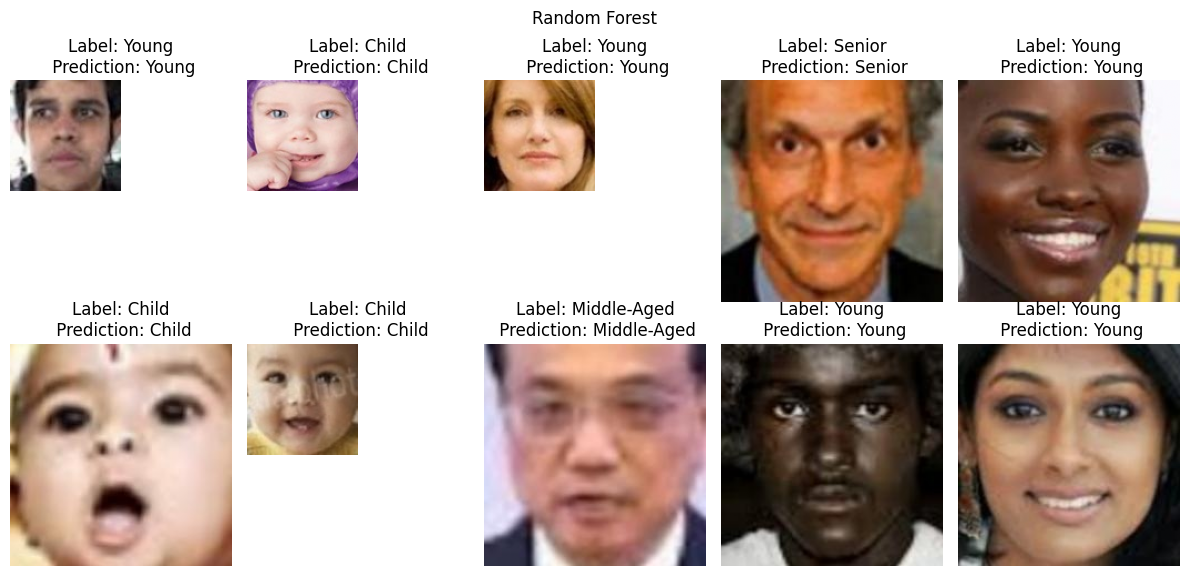

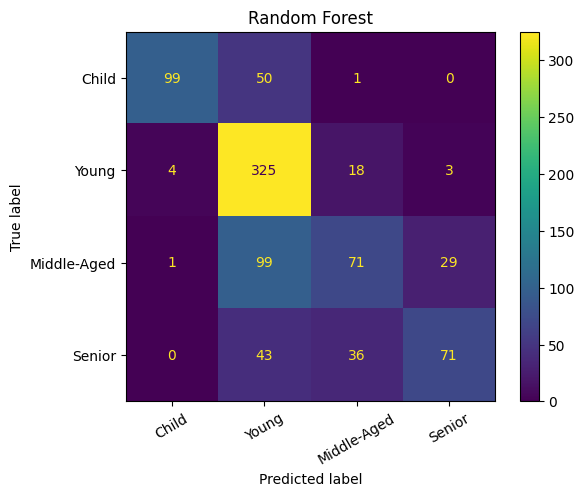

Classification report for Random Forest:

                    precision    recall  f1-score   support

       Child       0.95      0.66      0.78       150
       Young       0.63      0.93      0.75       350
 Middle-Aged       0.56      0.35      0.44       200
      Senior       0.69      0.47      0.56       150

    accuracy                           0.67       850
   macro avg       0.71      0.60      0.63       850
weighted avg       0.68      0.67      0.65       850



In [8]:
# Reference: Lab_05_Solved.ipynb (1: Digit classification with Support Vector Machines (SVMs))
CLASS_NAMES = [AGE_LABELS[i] for i in range(4)]

for name, clf in [('Linear SVM', classifier_linear), ('RBF SVM', classifier_rbf), ('Random Forest', classifier_rf)]:
    y_pred = clf.predict(X_test)

    sample_idx = np.random.default_rng(SEED).choice(len(test_paths), size=10, replace=False)
    fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(12, 6), sharex=True, sharey=True)
    ax = axes.ravel()
    for i, idx in enumerate(sample_idx):
        ax[i].imshow(read_rgb(test_paths[idx]))
        ax[i].set_title(f'Label: {AGE_LABELS[int(y_test[idx])]}\n Prediction: {AGE_LABELS[int(y_pred[idx])]}')
        ax[i].set_axis_off()
    plt.suptitle(name)
    plt.tight_layout()
    plt.show()

    metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=CLASS_NAMES, xticks_rotation=30)
    plt.title(name)
    plt.show()

    print(f"""Classification report for {name}:\n
      {metrics.classification_report(y_test, y_pred, target_names=CLASS_NAMES)}""")